In [ ]:
import pandas as pd
import numpy as np
import string
import spacy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns
%matplotlib inline
import re
from sklearn.naive_bayes import BernoulliNB
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
from multiprocessing import Pool, cpu_count
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import Model
# Download necessary NLTK data files
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df = pd.read_csv('Combined_Data.csv')

In [ ]:
df.status.value_counts()

,count
status,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


## 3.2 Exploratory Data Analysis

In [ ]:
# Dataset overview
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head(10))
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (53043, 3)

Column Names: ['Unnamed: 0', 'statement', 'status']

First few rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
5           5  every break, you must be nervous, like somethi...  Anxiety
6           6  I feel scared, anxious, what can I do? And may...  Anxiety
7           7    Have you ever felt nervous but didn't know why?  Anxiety
8           8  I haven't slept well for 2 days, it's like I'm...  Anxiety
9           9                 I'm really worried, I want to cry.  Anxiety

Data Types:
Unnamed: 0     int64
statement     object
status        object
dtype: object


Class Distribution:

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Class Percentages:

status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: proportion, dtype: float64


/tmp/ipython-input-2625754840.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


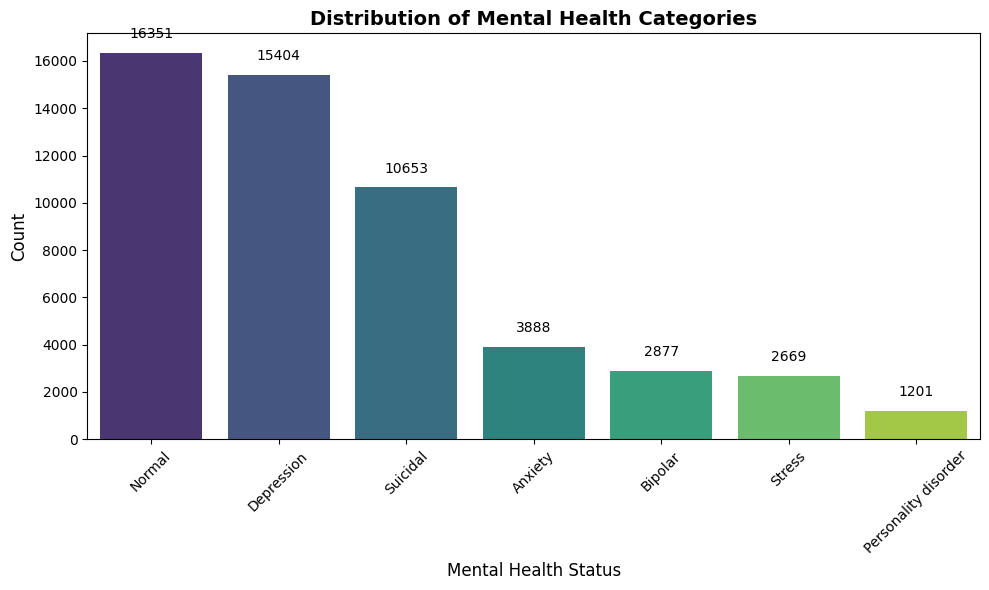


Class Imbalance Ratio: 13.61:1
⚠️ Significant class imbalance detected - will require handling (SMOTE, class weights, etc.)


In [ ]:
# Class distribution analysis
print("Class Distribution:\n")
class_counts = df['status'].value_counts()
print(class_counts)
print("\nClass Percentages:\n")
print(df['status'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Mental Health Categories', fontsize=14, fontweight='bold')
plt.xlabel('Mental Health Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Check for class imbalance
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("⚠️ Significant class imbalance detected - will require handling (SMOTE, class weights, etc.)")

Text Statistics by Category:

                     text_length                     word_count              \
                            mean      std min    max       mean     std min   
status                                                                        
Anxiety                   764.68   812.38   7   8539     143.84  152.63   1   
Bipolar                   946.07   952.51  27  26163     176.20  176.49   4   
Depression                844.03   953.00   3  19822     168.02  188.23   1   
Normal                     90.24   120.90   2   1358      17.25   22.77   1   
Personality disorder      956.73  1149.83  39  27588     179.35  221.89   5   
Stress                    613.55   570.07   6   8389     114.59  105.90   1   
Suicidal                  734.97   982.21   6  32759     146.44  186.96   1   

                            
                       max  
status                      
Anxiety               1592  
Bipolar               4804  
Depression            4239  
Norma

/tmp/ipython-input-3154556579.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='word_count', palette='Set2', ax=axes[1])


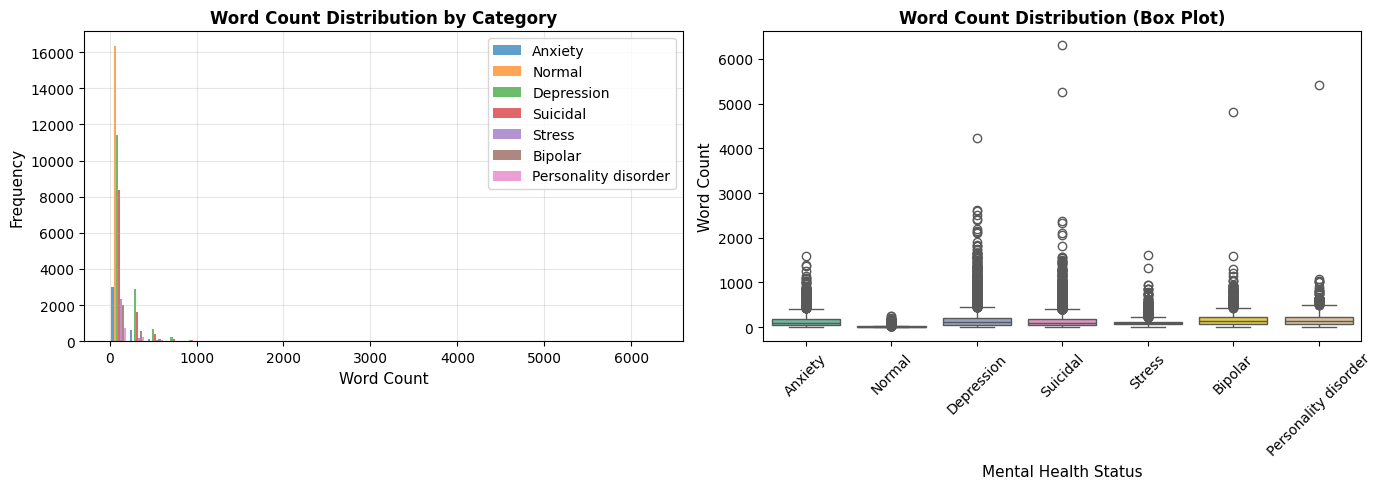

In [ ]:
# Text length analysis
# First, ensure no NaN values in statement column
df = df.dropna(subset=['statement'])

df['text_length'] = df['statement'].apply(lambda x: len(str(x)))
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

print("Text Statistics by Category:\n")
text_stats = df.groupby('status').agg({
    'text_length': ['mean', 'std', 'min', 'max'],
    'word_count': ['mean', 'std', 'min', 'max']
}).round(2)
print(text_stats)

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist([df[df['status'] == cat]['word_count'] for cat in df['status'].unique()],
             bins=30, label=df['status'].unique(), alpha=0.7)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Word Count Distribution by Category', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
sns.boxplot(data=df, x='status', y='word_count', palette='Set2', ax=axes[1])
axes[1].set_xlabel('Mental Health Status', fontsize=11)
axes[1].set_ylabel('Word Count', fontsize=11)
axes[1].set_title('Word Count Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3.3 Data Preprocessing Pipeline

In [ ]:
# Text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data
    - Lowercase conversion
    - Remove URLs, mentions, hashtags
    - Remove special characters (keep basic punctuation for context)
    - Remove extra whitespaces

    Note: For BERT, minimal preprocessing is used to preserve context
    For traditional ML, more aggressive cleaning may be applied
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions and hashtags (optional - may contain useful info)
    # text = re.sub(r'@\w+|#\w+', '', text)

    # Remove excessive punctuation but keep some (!!!, ???)
    text = re.sub(r'([!?.]){2,}', r'\1', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
df['cleaned_text'] = df['statement'].apply(preprocess_text)

# Display comparison
print("Original vs Cleaned Text (Sample):\n")
for i in range(5):
    print(f"Original: {df['statement'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i]}")
    print("-" * 80)

Original vs Cleaned Text (Sample):

Original: oh my gosh
Cleaned:  oh my gosh
--------------------------------------------------------------------------------
Original: trouble sleeping, confused mind, restless heart. All out of tune
Cleaned:  trouble sleeping, confused mind, restless heart. all out of tune
--------------------------------------------------------------------------------
Original: All wrong, back off dear, forward doubt. Stay in a restless and restless place
Cleaned:  all wrong, back off dear, forward doubt. stay in a restless and restless place
--------------------------------------------------------------------------------
Original: I've shifted my focus to something else but I'm still worried
Cleaned:  i've shifted my focus to something else but i'm still worried
--------------------------------------------------------------------------------
Original: I'm restless and restless, it's been a month now, boy. What do you mean?
Cleaned:  i'm restless and restless, it's b

In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['status'])

# Display label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:")
for category, encoded in label_mapping.items():
    print(f"  {category}: {encoded}")

# Save for later use
num_classes = len(label_encoder.classes_)
print(f"\nTotal number of classes: {num_classes}")

Label Encoding Mapping:
  Anxiety: 0
  Bipolar: 1
  Depression: 2
  Normal: 3
  Personality disorder: 4
  Stress: 5
  Suicidal: 6

Total number of classes: 7


In [ ]:
# Train-Test Split (Stratified to maintain class distribution)
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 42144
Test set size: 10537

Training set class distribution:
label
0     3073
1     2221
2    12323
3    13074
4      862
5     2070
6     8521
Name: count, dtype: int64

Test set class distribution:
label
0     768
1     556
2    3081
3    3269
4     215
5     517
6    2131
Name: count, dtype: int64


### 3.4.1 Baseline Model 1: Naive Bayes with TF-IDF

In [21]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation
print("\n" + "="*60)
print("NAIVE BAYES (TF-IDF) - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Macro F1-Score: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_, digits=4))

TF-IDF feature shape: (42144, 5000)

NAIVE BAYES (TF-IDF) - PERFORMANCE METRICS
Accuracy: 0.6829
Macro F1-Score: 0.5244
Weighted F1-Score: 0.6657

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.7345    0.6016    0.6614       768
             Bipolar     0.8682    0.4622    0.6033       556
          Depression     0.5511    0.7371    0.6307      3081
              Normal     0.8061    0.8749    0.8391      3269
Personality disorder     1.0000    0.0698    0.1304       215
              Stress     0.6316    0.0928    0.1619       517
            Suicidal     0.6928    0.6021    0.6442      2131

            accuracy                         0.6829     10537
           macro avg     0.7549    0.4915    0.5244     10537
        weighted avg     0.7021    0.6829    0.6657     10537



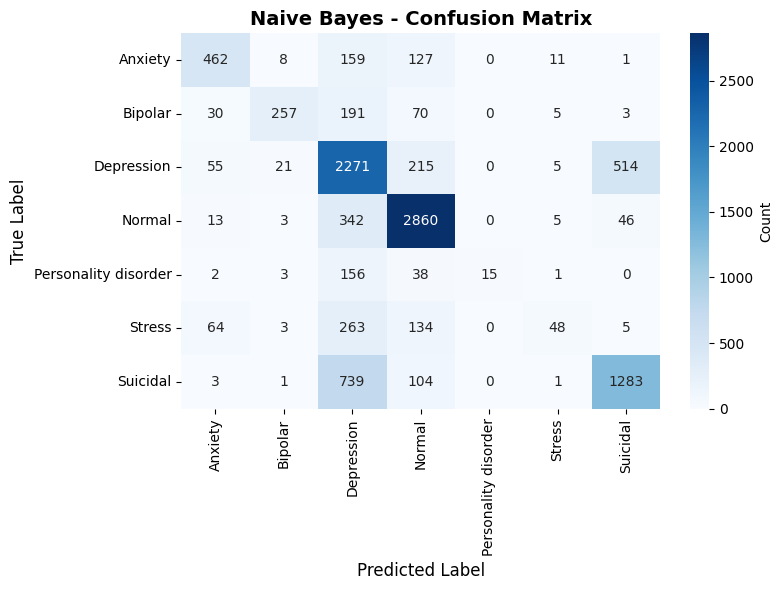

In [22]:
# Confusion Matrix for Naive Bayes
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Naive Bayes - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4.2 Baseline Model 2: Logistic Regression with TF-IDF


LOGISTIC REGRESSION (TF-IDF) - PERFORMANCE METRICS
Accuracy: 0.7533
Macro F1-Score: 0.6994
Weighted F1-Score: 0.7545

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.7617    0.7865    0.7739       768
             Bipolar     0.7028    0.8040    0.7500       556
          Depression     0.8037    0.5914    0.6814      3081
              Normal     0.8899    0.9070    0.8983      3269
Personality disorder     0.4294    0.7209    0.5382       215
              Stress     0.4623    0.6750    0.5487       517
            Suicidal     0.6669    0.7489    0.7056      2131

            accuracy                         0.7533     10537
           macro avg     0.6738    0.7477    0.6994     10537
        weighted avg     0.7700    0.7533    0.7545     10537



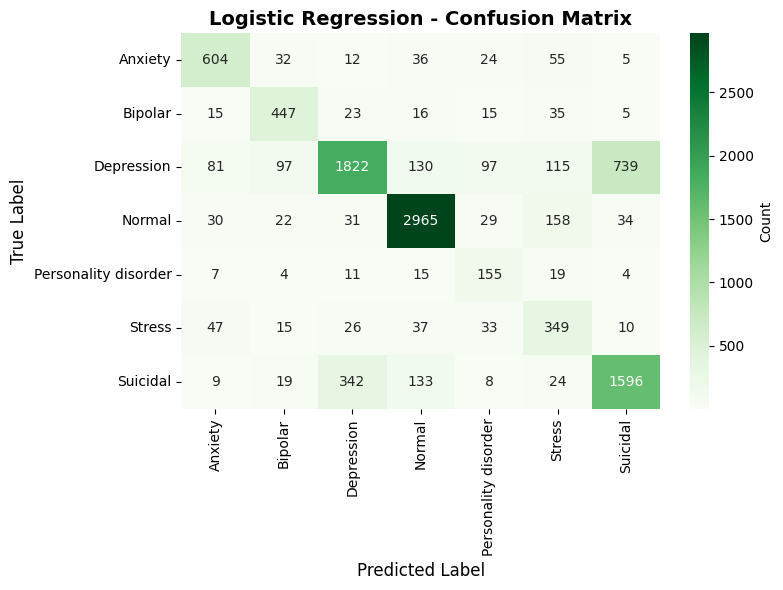

In [23]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
print("\n" + "="*60)
print("LOGISTIC REGRESSION (TF-IDF) - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Macro F1-Score: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_, digits=4))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4.3 Deep Learning Model 1: BiLSTM with Word Embeddings

In [24]:
# Tokenization for LSTM (using Keras Tokenizer)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Tokenization
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Training sequences shape: (42144, 100)
Test sequences shape: (10537, 100)
Vocabulary size: 55594


In [25]:
# Build BiLSTM Model
def build_bilstm_model(vocab_size, num_classes, embedding_dim=128, lstm_units=64):
    """
    BiLSTM Architecture:
    - Embedding Layer (learns word representations)
    - Bidirectional LSTM (captures context from both directions)
    - GlobalMaxPooling (extracts most important features)
    - Dense layers with Dropout (prevents overfitting)
    - Output layer with softmax (multi-class classification)
    """
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        Bidirectional(LSTM(lstm_units, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize model
lstm_model = build_bilstm_model(vocab_size=max_words, num_classes=num_classes)
print(lstm_model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/15
527/527 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.4959 - loss: 1.3174 - val_accuracy: 0.6594 - val_loss: 0.8128 - learning_rate: 0.0010
Epoch 2/15
527/527 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6454 - loss: 0.8253 - val_accuracy: 0.6752 - val_loss: 0.7589 - learning_rate: 0.0010
Epoch 3/15
527/527 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7054 - loss: 0.7070 - val_accuracy: 0.7205 - val_loss: 0.6877 - learning_rate: 0.0010
Epoch 4/15
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7716 - loss: 0.5890 - val_accuracy: 0.7294 - val_loss: 0.7074 - learning_rate: 0.0010
Epoch 5/15
524/527 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7992 - loss: 0.5166
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
527/527 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7993 - loss: 0.5164 - val_accuracy: 0.7515 - val_loss: 0.6980 - learning_rate: 0.0010
Epoch 6/15
527/527 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8396 - loss: 0.

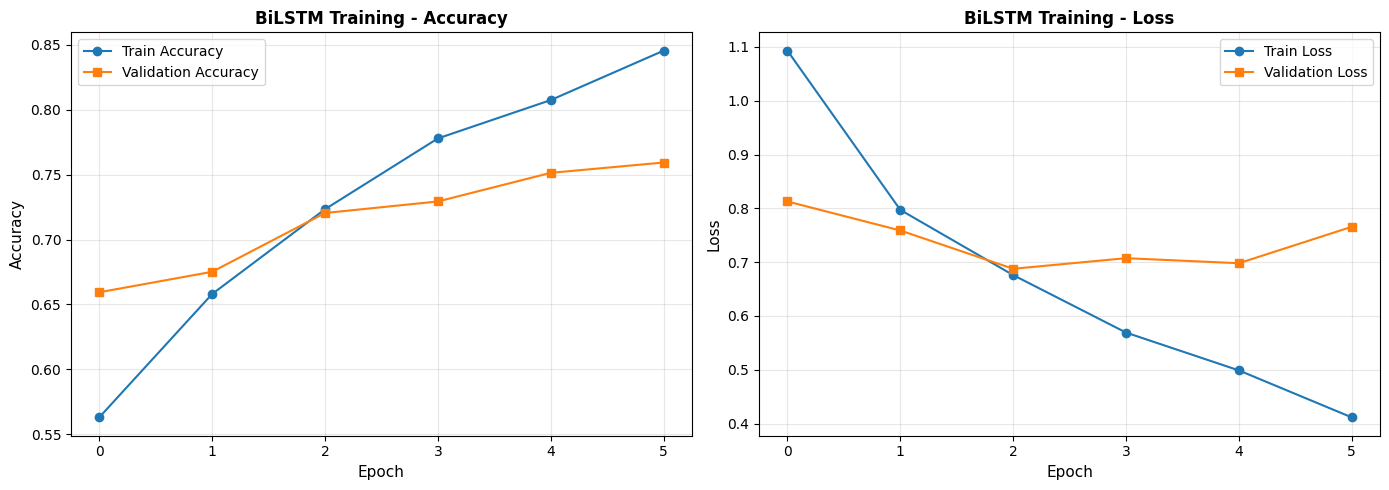

In [26]:
# Train BiLSTM Model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('BiLSTM Training - Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('BiLSTM Training - Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

BiLSTM - PERFORMANCE METRICS
Accuracy: 0.7185
Macro F1-Score: 0.5901
Weighted F1-Score: 0.7081

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.6839    0.8255    0.7481       768
             Bipolar     0.8863    0.6871    0.7741       556
          Depression     0.7847    0.4638    0.5830      3081
              Normal     0.9195    0.9226    0.9211      3269
Personality disorder     0.0000    0.0000    0.0000       215
              Stress     0.3888    0.4971    0.4363       517
            Suicidal     0.5423    0.8695    0.6680      2131

            accuracy                         0.7185     10537
           macro avg     0.6008    0.6094    0.5901     10537
        weighted avg     0.7401    0.7185    0.7081     10537



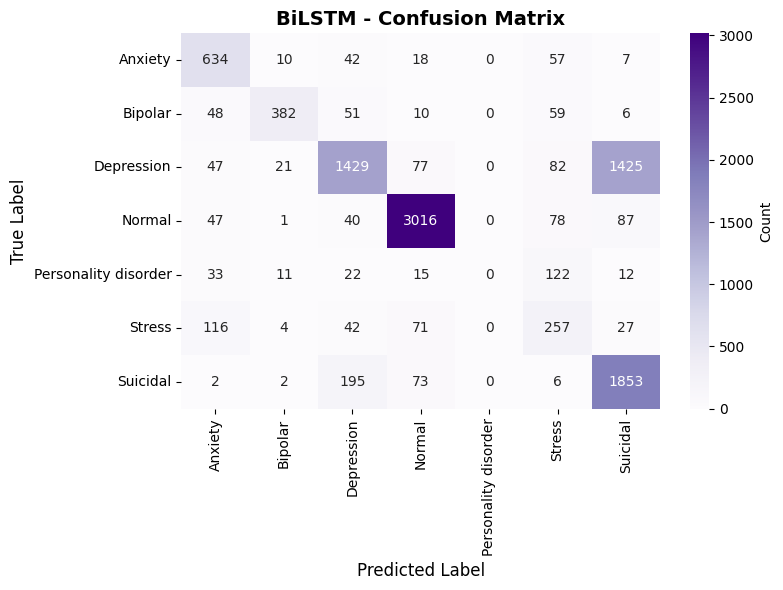

In [27]:
# Evaluate BiLSTM Model
y_pred_lstm_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

# Metrics
print("\n" + "="*60)
print("BiLSTM - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Macro F1-Score: {f1_score(y_test, y_pred_lstm, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_lstm, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=label_encoder.classes_, digits=4))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('BiLSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4.4 Deep Learning Model 2: Fine-Tuned BERT (DistilBERT)

**Note:** BERT fine-tuning requires significant computational resources. We'll use DistilBERT (a lighter version) with the Hugging Face Transformers library.

**Install required libraries (if not already installed):**
```bash
pip install transformers torch
```

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import DataCollatorWithPadding
import torch
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pre-trained DistilBERT tokenizer
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize data
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

Using device: cuda


In [16]:
# Tokenize training and test data
print("Tokenizing training data...")
train_encodings = tokenize_data(X_train, bert_tokenizer, max_length=128)
print("Tokenizing test data...")
test_encodings = tokenize_data(X_test, bert_tokenizer, max_length=128)

# Load pre-trained DistilBERT model for sequence classification (PyTorch)
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_classes
)

# Move model to GPU if available
bert_model = bert_model.to(device)

print(f"DistilBERT Model Loaded and moved to: {device}")
print(f"Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}")

Tokenizing training data...
Tokenizing test data...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT Model Loaded and moved to: cuda
Total parameters: 66,958,855
Trainable parameters: 66,958,855


Starting DistilBERT fine-tuning...
Training on device: cuda
Mixed precision (FP16): True


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.293700,0.582267,0.801082,0.768358,0.795697
2,0.278700,0.491407,0.822056,0.800626,0.822837
3,0.158600,0.701374,0.818165,0.801478,0.818344



Training completed!
Best model saved at: ./results


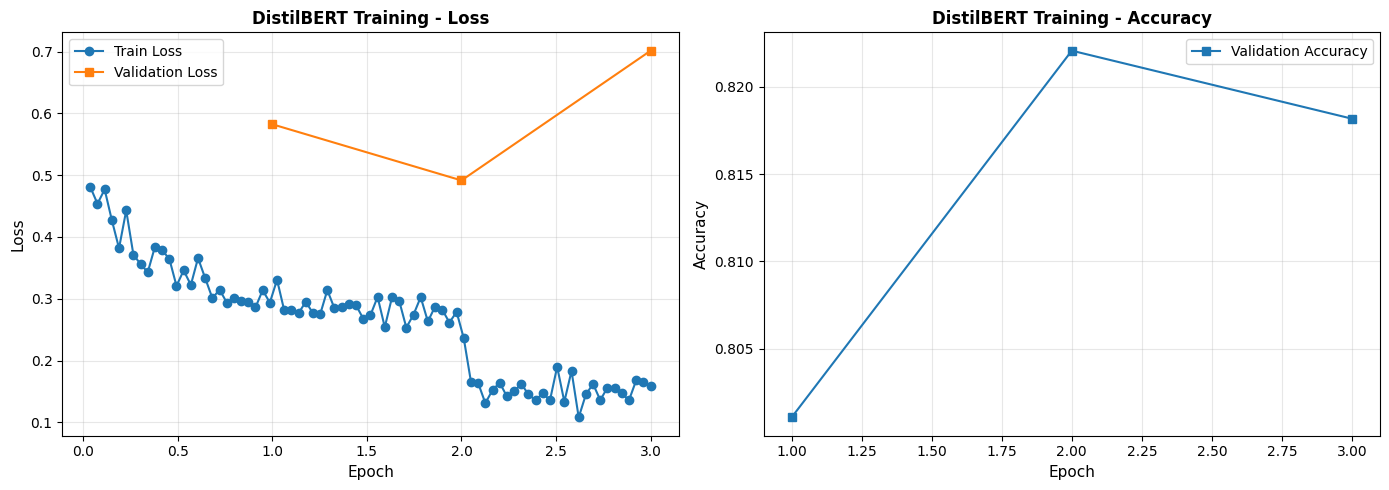

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Create PyTorch datasets
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = MentalHealthDataset(train_encodings, y_train)
test_dataset = MentalHealthDataset(test_encodings, y_test)

# Training configuration
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",  # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    dataloader_num_workers=0,
)

# Define compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Initialize Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Fine-tune DistilBERT
print("Starting DistilBERT fine-tuning...")
print(f"Training on device: {device}")
print(f"Mixed precision (FP16): {training_args.fp16}")
print("="*60)

history_bert = trainer.train()

# Get training history for plotting
train_metrics = []
eval_metrics = []
for log in trainer.state.log_history:
    if 'loss' in log and 'epoch' in log:
        train_metrics.append({'epoch': log['epoch'], 'loss': log['loss']})
    if 'eval_loss' in log:
        eval_metrics.append({'epoch': log['epoch'], 'eval_loss': log['eval_loss'],
                            'eval_accuracy': log.get('eval_accuracy', 0)})

print("\nTraining completed!")
print(f"Best model saved at: {training_args.output_dir}")

# Plot training history
if train_metrics and eval_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    train_epochs = [m['epoch'] for m in train_metrics]
    train_loss = [m['loss'] for m in train_metrics]
    eval_epochs = [m['epoch'] for m in eval_metrics]
    eval_loss = [m['eval_loss'] for m in eval_metrics]

    axes[0].plot(train_epochs, train_loss, label='Train Loss', marker='o')
    axes[0].plot(eval_epochs, eval_loss, label='Validation Loss', marker='s')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('DistilBERT Training - Loss', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    eval_acc = [m['eval_accuracy'] for m in eval_metrics]
    axes[1].plot(eval_epochs, eval_acc, label='Validation Accuracy', marker='s')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy', fontsize=11)
    axes[1].set_title('DistilBERT Training - Accuracy', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


Evaluating DistilBERT Model on Test Set



DistilBERT - PERFORMANCE METRICS
Accuracy: 0.8221
Macro F1-Score: 0.8006
Weighted F1-Score: 0.8228

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.8838    0.8815    0.8827       768
             Bipolar     0.8523    0.8507    0.8515       556
          Depression     0.7732    0.7556    0.7643      3081
              Normal     0.9614    0.9452    0.9533      3269
Personality disorder     0.6906    0.7163    0.7032       215
              Stress     0.7115    0.7679    0.7386       517
            Suicidal     0.6982    0.7241    0.7109      2131

            accuracy                         0.8221     10537
           macro avg     0.7958    0.8059    0.8006     10537
        weighted avg     0.8239    0.8221    0.8228     10537



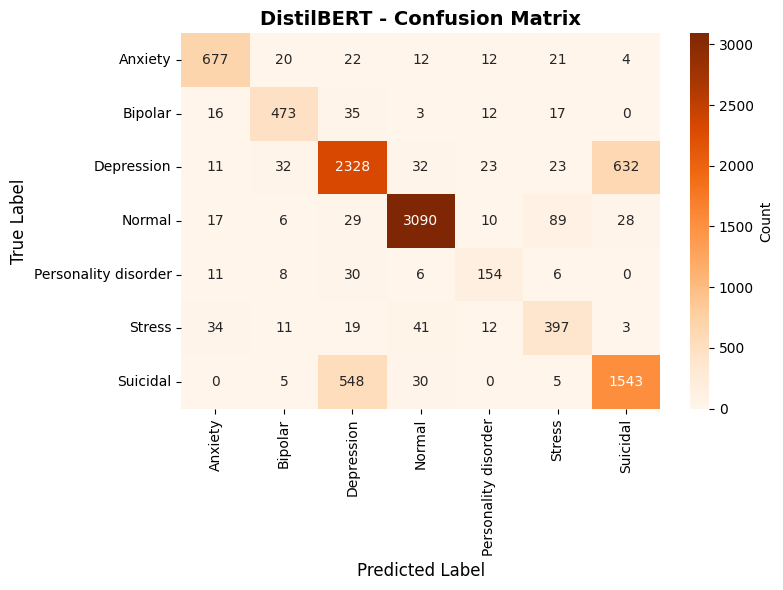

In [19]:
# Evaluate DistilBERT Model using PyTorch
print("\n" + "="*60)
print("Evaluating DistilBERT Model on Test Set")
print("="*60)

# Get predictions using the trainer
predictions = trainer.predict(test_dataset)

# Extract logits and convert to class predictions
y_pred_bert_logits = predictions.predictions
y_pred_bert = np.argmax(y_pred_bert_logits, axis=1)

# Metrics
print("\n" + "="*60)
print("DistilBERT - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"Macro F1-Score: {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_bert, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bert, target_names=label_encoder.classes_, digits=4))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_bert = confusion_matrix(y_test, y_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('DistilBERT - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Results

## 4.1 Model Performance Comparison


COMPREHENSIVE MODEL COMPARISON - RESEARCH QUESTION 1
                       Model  Accuracy  Macro F1-Score  Weighted F1-Score
        Naive Bayes (TF-IDF)  0.682927        0.524429           0.665656
Logistic Regression (TF-IDF)  0.753345        0.699442           0.754516
                      BiLSTM  0.718516        0.590079           0.708097
                  DistilBERT  0.822056        0.800626           0.822837


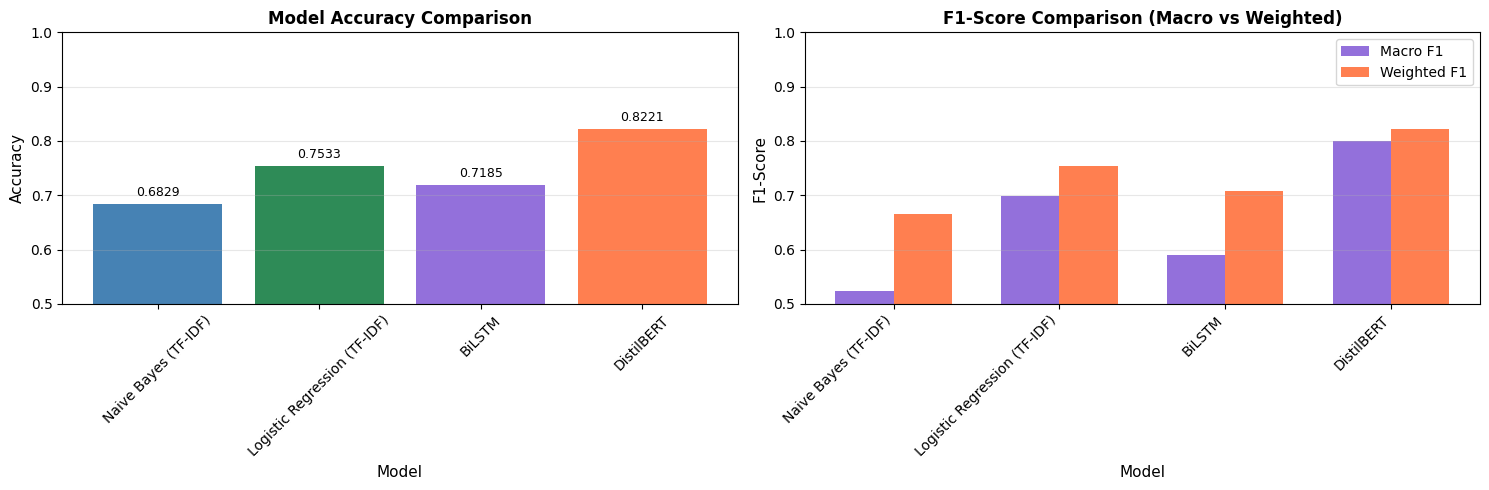

In [28]:
# Compile results from all models
results_summary = {
    'Model': ['Naive Bayes (TF-IDF)', 'Logistic Regression (TF-IDF)', 'BiLSTM', 'DistilBERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lstm),
        accuracy_score(y_test, y_pred_bert)
    ],
    'Macro F1-Score': [
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_lstm, average='macro'),
        f1_score(y_test, y_pred_bert, average='macro')
    ],
    'Weighted F1-Score': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_lstm, average='weighted'),
        f1_score(y_test, y_pred_bert, average='weighted')
    ]
}

results_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON - RESEARCH QUESTION 1")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=['steelblue', 'seagreen', 'mediumpurple', 'coral'])
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim([0.5, 1.0])
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# F1-Score comparison
x = np.arange(len(results_df['Model']))
width = 0.35
axes[1].bar(x - width/2, results_df['Macro F1-Score'], width, label='Macro F1', color='mediumpurple')
axes[1].bar(x + width/2, results_df['Weighted F1-Score'], width, label='Weighted F1', color='coral')
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score Comparison (Macro vs Weighted)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Per-Class F1-Scores:
                      Naive Bayes  Logistic Regression  BiLSTM  DistilBERT
Anxiety                    0.6614               0.7739  0.7481      0.8827
Bipolar                    0.6033               0.7500  0.7741      0.8515
Depression                 0.6307               0.6814  0.5830      0.7643
Normal                     0.8391               0.8983  0.9211      0.9533
Personality disorder       0.1304               0.5382  0.0000      0.7032
Stress                     0.1619               0.5487  0.4363      0.7386
Suicidal                   0.6442               0.7056  0.6680      0.7109


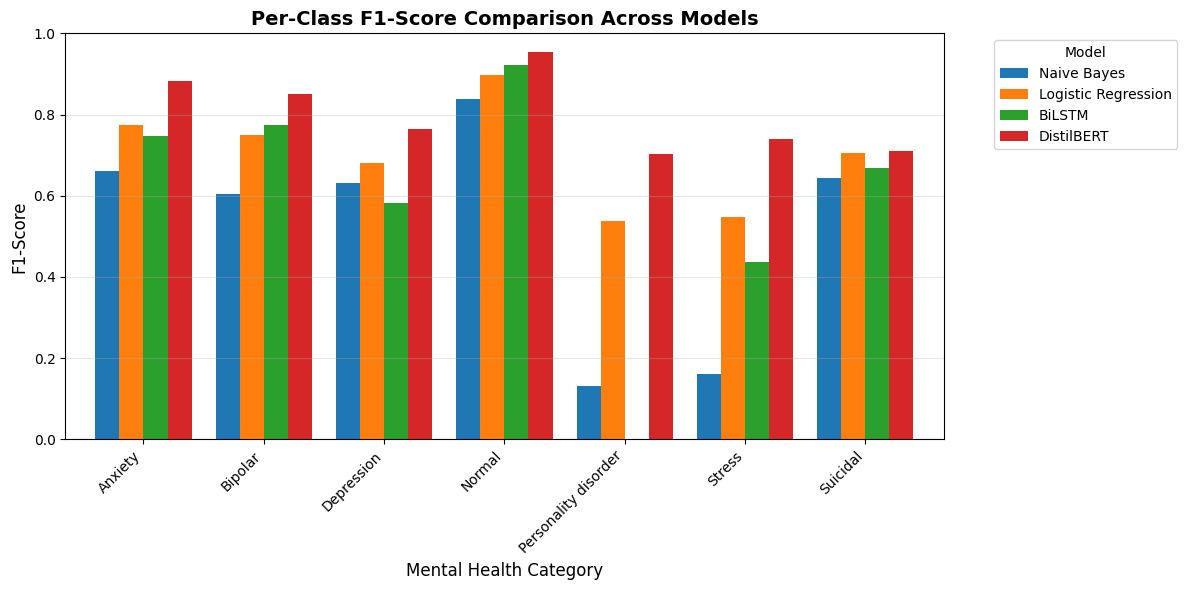

In [29]:
# Per-class F1-Score comparison
from sklearn.metrics import f1_score

# Calculate per-class F1 scores for all models
models = {
    'Naive Bayes': y_pred_nb,
    'Logistic Regression': y_pred_lr,
    'BiLSTM': y_pred_lstm,
    'DistilBERT': y_pred_bert
}

class_f1_scores = {}
for model_name, y_pred in models.items():
    f1_per_class = f1_score(y_test, y_pred, average=None)
    class_f1_scores[model_name] = f1_per_class

# Create DataFrame
class_f1_df = pd.DataFrame(class_f1_scores, index=label_encoder.classes_)
print("\nPer-Class F1-Scores:")
print(class_f1_df.round(4))

# Visualize per-class performance
class_f1_df.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Per-Class F1-Score Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Mental Health Category', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()